In [1]:
from scipy.optimize import fsolve
import formulas as fo
import constants as co
import interpolation as ip
import plotting as pl
import extrapolation as ex
from uncertainties import ufloat
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import lmfit as lm
import seaborn as sns
from headers import HEADER_ERR_SUFFIX

sns.set_context("paper")
data_path = Path('data')
figure_path = Path('figures')


Here we are seeking the magnetoresistivity (MR) $\left(\rho_{MR}\right)$ of the sample as a function of the magnetic flux density $\left(\rho\left(B\right)\right)$ at 2K, 5K, 10K and 15K in the fields 0.5T, 3T, 7T and 9T. We will then compare $\rho$ values against the AMRO resistivity at sample orientations 0 and 90 degrees. Since $B$ is dependent on the demagnetization factor $\left(D\right)$ via,

(SI) 

$B = \mu_0\left(H + M-M_D\right) = \mu_0\left(H + (1-D)M\right)$ 

(CGS) 

$B =  H + 4\pi (M-M_D) = H + 4\pi(1-D)M$

where $M$ is the magnetization per volume, which we obtain via the magnetic moment $(m)$ measured in Brazil. 

Thus we must determine the MR data $(\rho_{MR})$ as a function of total magnetic flux $(B)$, using the magnetization data. Then we will calculate the $B$ values for the AMRO data at two orientations, $90^\circ$ and $0^\circ$, making use of the magnetization calculations.

Unfortuantely, since we don't have magnetization data for the samples that were used to take the AMRO and MR data, we must assume that the volume magnetization will be constant between these samples so long as the applied magnetic field $H$ is the same.

This document will work in CGS units for all calculations, until it is time to make nice graphs.

Source: https://en.wikipedia.org/wiki/Demagnetizing_field

# Obtain M(B)

We require this magnetization data in order to calculate the total magnetic flux $(B)$ for the $\rho_{MR}$ data and the AMRO data. Making use of a Chebyshev polynomial, we interpolate the data such that we may plug in an arbitrary applied field $H$ and extract a magnetization at the given temperature at that field strength.

Since the Brazil data was unable to reach 9T, we will also fit a Brillouin function to calculate an approximate magnetization at 9T for each temperature.

## Load the Magnetization Data

In [2]:

col_choice = ['Temperature (K)', 'Magnetic Field (Oe)', 'Moment (emu)', 'T']

rows = []
for fp in list(data_path.glob('*.dat')):
    df = pd.read_table(fp, skiprows=39, sep=',')
    df['T'] = df['Temperature (K)'].round(1)
    df['H'] = fo.convert_oe_to_teslas(df['Magnetic Field (Oe)']).round(1)
    rows.append(df)

mag_data = pd.concat(rows)
mag_data = mag_data[col_choice]

mag_data.head()

,Temperature (K),Magnetic Field (Oe),Moment (emu),T
0,10.000247,-0.269667,-0.000016,10.0
1,9.999907,1000.279602,0.000893,10.0
2,9.999962,2000.326294,0.001797,10.0
3,10.000063,3000.495605,0.002698,10.0
4,9.999810,4000.187012,0.003596,10.0


## Calculate $B(M_{vol})$ for the Magnetization Data

In [3]:
# Define the dimensions of the sample used
a_Brazil = 0.21070  # cm
b_Brazil = 0.08766  # cm
c_Brazil = 0.09315  # cm, B-Field ||

sample_mass = 0.00268  # g
mass_density_YbPdBi = 11.396  #  g/cm^3, determined from XRD
volume_brazil2 = sample_mass / mass_density_YbPdBi  # g * (cm^3/g)


volume_Brazil = a_Brazil*b_Brazil*c_Brazil  # cm^3
nVol = (sample_mass / co.YbPdBi_molar_mass * co.Na) / volume_Brazil

D_factor_Brazil = fo.DemagFactor(a_Brazil / 2.0, b_Brazil / 2.0, c_Brazil / 2.0)


We will calculate the volume magnetization from the data, and multiply by $4\pi$ in order to obtain the magnetization field, which replace the magnetization term in the equation for $B$

In [4]:

mag_data['Magnetization (emu/cm^3)'] = mag_data['Moment (emu)']  / volume_Brazil
mag_data['Magnetization (emu/g)'] = mag_data['Moment (emu)']  / sample_mass
mag_data['Magnetic Flux Density (G)']  = mag_data['Magnetic Field (Oe)'] + (4*np.pi)*(1-D_factor_Brazil) * mag_data['Magnetization (emu/cm^3)']


# Extrapolate M(B) to $\mu_0H=9$T

Since the data from Brazil has a maximum applied field strength of 7T, we need to approximate the magnetization at 9T in order to check demagnetization effects at this field strength.

## Try Fitting with J as a parameter


In [5]:


#######################################################################################
#######################################################################################
#######################################################################################

x_label = 'Magnetic Field (Oe)'
y_label = 'Magnetization (emu/cm^3)'

lmfit_params_df = pd.DataFrame()
raw_results = {}


###### FITTING #######
mag_func_dict = {}
H_ticks = np.linspace(0,9, 4)
temp_choices = [2, 5, 10, 15]
for i, T in enumerate(temp_choices):

    # Query the relevant magnetization data
    mag_hunt_df =  mag_data.query('T == {}'.format(T)).drop('Magnetic Flux Density (G)', axis=1)

    # Extract experimental data
    M_vals = mag_hunt_df[y_label].values
    H_vals = mag_hunt_df[x_label].values
    T_vals = mag_hunt_df['Temperature (K)'].values

    ###### FITTING #######
    # Create the Model, then declare independant variables and fit parameters
    gmodel = lm.Model(func = fo.magnetization, independent_vars = ['H','M', 'D', 'T'])#, param_names=['M0','A','C'])

    if T in ( 10, 15):
        gmodel.set_param_hint('C', value=0, vary=False)
        gmodel.set_param_hint('n', value=nVol, vary=False)
    elif T == 5:
        gmodel.set_param_hint('C', value=0, vary=True)
        gmodel.set_param_hint('n', value=nVol, vary=False)
    else:
        gmodel.set_param_hint('C', value=0, vary=True)
        gmodel.set_param_hint('n', value=nVol, vary=True)

    gmodel.set_param_hint('J', value=7/2, vary=True)

    # Perform the fit on the Model
    result = gmodel.fit(M_vals, H=H_vals, M=M_vals, D=D_factor_Brazil, T=T_vals)
    raw_results[T] = result

    params_df = {}
    for key in result.params.keys():
        params_df[key] = result.params[key].value
        params_df[key+HEADER_ERR_SUFFIX] = result.params[key].stderr
    params_df['T'] = float(T)
    params_df['D'] = D_factor_Brazil
    params_df = pd.DataFrame(params_df, index=[0])
    
    # Store params in a dataframe
    lmfit_params_df = pd.concat([lmfit_params_df, params_df])
    
    # Store function in dict to be called later with different H
    # NOTE: May not work since magnetization is on both sides...
    mag_func_dict[str(T)] = result.eval




## Extrapolate Magnetization

In [6]:

###### EXTRAPOLATION #######
dfs = []
for i, T in enumerate(temp_choices):

    params_df = lmfit_params_df.query(f"T=={T}")
    mag_hunt_df =  mag_data.query('T == {}'.format(T)).drop('Magnetic Flux Density (G)', axis=1)

   # Extract experimental data
    M_vals = mag_hunt_df[y_label].values
    H_vals = mag_hunt_df[x_label].values
    T_vals = mag_hunt_df['Temperature (K)'].values
    #
    # H_interval = 5*int(H_vals[-1]-H_vals[-2])
    # num_H_points = (90000 - max(H_vals))/H_interval
    fake_H_vals =  np.linspace(max(H_vals), 90000, 10)

    fake_M_vals = ex.solve_for_magnetization(fake_H_vals, D_factor_Brazil, T,
                                  params_df['J'].values[0],
                                  params_df['C'].values[0],
                                  params_df['n'].values[0])
    max_M_vals = ex.solve_for_magnetization(fake_H_vals, D_factor_Brazil, T,
                                 params_df['J'].values[0]+params_df['J'+HEADER_ERR_SUFFIX],
                                 params_df['C'].values[0]+params_df['C'+HEADER_ERR_SUFFIX],
                                 params_df['n'].values[0]+params_df['n'+HEADER_ERR_SUFFIX])
    min_M_vals = ex.solve_for_magnetization(fake_H_vals, D_factor_Brazil, T,
                                 params_df['J'].values[0]-params_df['J'+HEADER_ERR_SUFFIX],
                                 params_df['C'].values[0]-params_df['C'+HEADER_ERR_SUFFIX],
                                 params_df['n'].values[0]-params_df['n'+HEADER_ERR_SUFFIX])

    # Pack and Append Extrapolated data
    temp_df = pd.DataFrame({'T': T,
                           'Temperature (K)': T,
                           'Magnetic Field (Oe)': fake_H_vals,
                            y_label : fake_M_vals,
                            y_label+"_err_max":max_M_vals,
                            y_label+"_err_min":min_M_vals}
                            )

    dfs.append(temp_df)

extrap_mag_df = pd.concat(dfs)



# Plot the Extrapolation Results

T = 2 , min residual: -2.074135815066025 , max residual: 98.87890297466353


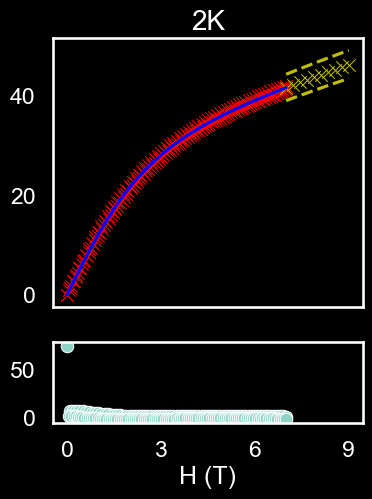

T = 5 , min residual: -0.36502721629617535 , max residual: 97.48256178609425


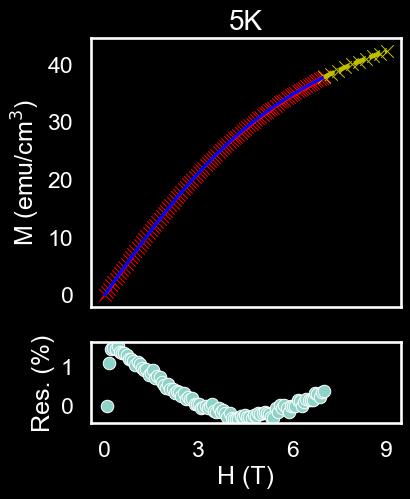

T = 10 , min residual: -4.441721122226757 , max residual: 98.87049174376602


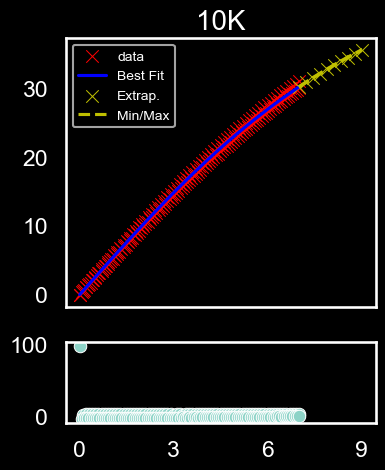

T = 15 , min residual: -3.1077373476626757 , max residual: 101.89674896378065


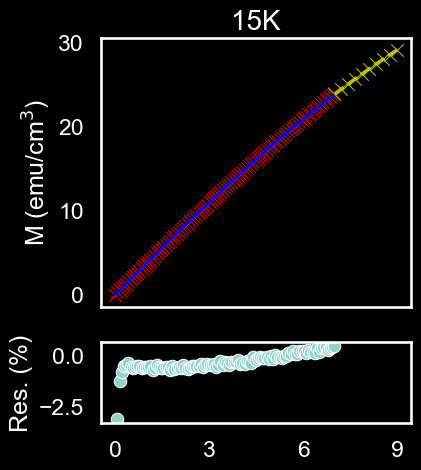

In [7]:
for i, T in enumerate(temp_choices):

    q = f'T == {T}'
    original_data_df =  mag_data.query(q).drop('Magnetic Flux Density (G)', axis=1)
    extrap_data_df = extrap_mag_df.query(q)
    fit_params_df = lmfit_params_df.query(q)


    # Extract experimental data
    M_vals = original_data_df[y_label].values
    H_vals = original_data_df[x_label].values
    # T_vals = original_data_df['Temperature (K)'].values
    fake_H_vals =  extrap_data_df['Magnetic Field (Oe)'].values
    fake_M_vals =extrap_data_df[y_label].values
    max_M_vals= extrap_data_df[y_label+"_err_max"].values
    min_M_vals=extrap_data_df[y_label+"_err_min"].values

    result = raw_results[T]

    ###### PLOTTING #######
    # TODO: Separate this out into a separate loop, no need to do it at the same time.
    sns.set_context('talk')
    fig, axs = plt.subplots(2,1, sharex=True, sharey=False, gridspec_kw={'height_ratios': [1, 0.3]})
    fig.set_size_inches(4,5)

    # Select relevant plotting axes
    fit_ax = axs[0]#[i]
    res_ax = axs[1]#[i]

    # sns.set_context('paper')
    x_plot = H_vals/10000

    # data
    sns.scatterplot(x= x_plot, y=M_vals, marker='x', ax=fit_ax, color='r', label='data')
    # Best Fit
    sns.lineplot(x=x_plot, y = result.best_fit, ax=fit_ax, color='b', label='Best Fit')
    # Residuals
    print('T =', T, ', min residual:', min(result.residual/M_vals*100), ', max residual:', max(result.residual/M_vals*100))
    sns.scatterplot(x=H_vals[1:]/10000,
                    y=(result.residual/M_vals*100)[1:],
                    ax=res_ax)
    # Extrapolations
    sns.scatterplot(x= fake_H_vals/10000,
                    y=fake_M_vals,
                    marker='x', ax=fit_ax, color='y', label='Extrap.')
    sns.lineplot(x= fake_H_vals/10000,
                 y=max_M_vals,
                 color='y', marker='None', ax=fit_ax, linestyle='--', label='Min/Max')
    sns.lineplot(x= fake_H_vals/10000,
                 y=min_M_vals,
                 color='y', marker='None', ax=fit_ax, linestyle='--')


    # Do the formatting stuff
    fit_ax.legend(loc='best')#(0.55, 0.2))
    fit_ax.set_xticks(H_ticks)
    res_ax.set_xticks(H_ticks)

    fit_ax.set_ylabel(r'M (emu/cm$^3$)')
    res_ax.set_xlabel('H (T)')

    plot_title = str(T)
    fit_ax.set_title(plot_title+"K", size=20)

    # Add gridlines
    fit_ax.grid()
    res_ax.grid()

    # Modify labels and legends for visual clarity
    if T == 2:
        fit_ax.legend().remove()
        fit_ax.set_ylabel(None)

    elif T == 5:
        fit_ax.legend().remove()
        res_ax.set_ylabel('Res. (%)')
    elif T == 10:
        fit_ax.legend(prop={'size':10})
        fit_ax.set_xlabel(None)
        res_ax.set_xlabel(None)
        fit_ax.set_ylabel(None)
        res_ax.set_ylabel(None)


    elif T == 15:
        fit_ax.legend().remove()
        fit_ax.set_xlabel(None)
        res_ax.set_xlabel(None)
        res_ax.set_ylabel('Res. (%)')

    # i+=1
    fig.savefig(figure_path/'Brillouin Fits and Extrapolation, Linear Term with L {}K.pdf'.format(T), dpi=300, transparent=False, bbox_inches='tight')
    plt.show()


# Calc the Saturation Magnetization

In [8]:



# Calc saturization magnetization
M = []
M_err = []
for i, row in lmfit_params_df.iterrows():

    n = ufloat(row['n'], row['n'+HEADER_ERR_SUFFIX])
    J = ufloat(row['J'], row['J'+HEADER_ERR_SUFFIX])
    if n.s==0 or J.s==0:
        print(row)
    M0 = n * fo.lange_g_factor(J) * co.mub_CGS * J

    M.append(M0.nominal_value)
    M_err.append(M0.std_dev)

lmfit_params_df['M0'] =  M
lmfit_params_df['M0'+HEADER_ERR_SUFFIX] =  M_err

lmfit_params_df['C (T)'] = lmfit_params_df['C'] * 10000
lmfit_params_df['C (T)'+HEADER_ERR_SUFFIX]= lmfit_params_df['C'+HEADER_ERR_SUFFIX] * 10000

lmfit_params_df['n (mols)'] = lmfit_params_df['n'] / co.Na
lmfit_params_df['n (mols)'+HEADER_ERR_SUFFIX]= lmfit_params_df['n'+HEADER_ERR_SUFFIX] / co.Na


lmfit_params_df.reset_index(drop=True, inplace=True)
extrap_mag_df.reset_index(drop=True, inplace=True)
# pd.options.display.float_format = '{:.0f}'.format

print("lmfit Fit Brillouin Results")
print(lmfit_params_df.sort_values('T', ascending=False))
print('\n')


J        1.916727e+00
J_err    3.236793e-03
C        6.020111e-05
C_err    9.735501e-07
n        1.920550e+21
n_err    0.000000e+00
T        5.000000e+00
D        4.008569e-01
Name: 0, dtype: float64
J        2.525055e+00
J_err    2.905796e-03
C        0.000000e+00
C_err    0.000000e+00
n        1.920550e+21
n_err    0.000000e+00
T        1.000000e+01
D        4.008569e-01
Name: 0, dtype: float64
J        2.686059e+00
J_err    6.058304e-04
C        0.000000e+00
C_err    0.000000e+00
n        1.920550e+21
n_err    0.000000e+00
T        1.500000e+01
D        4.008569e-01
Name: 0, dtype: float64
lmfit Fit Brillouin Results
          J     J_err         C         C_err             n         n_err  \
3  2.686059  0.000606  0.000000  0.000000e+00  1.920550e+21  0.000000e+00   
2  2.525055  0.002906  0.000000  0.000000e+00  1.920550e+21  0.000000e+00   
1  1.916727  0.003237  0.000060  9.735501e-07  1.920550e+21  0.000000e+00   
0  1.542950  0.065895  0.000207  6.996536e-06  1.475427e+21  6.9

C:\Users\jdcf5\anaconda3\Lib\site-packages\uncertainties\core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


### Plot the Fit Parameters

In [9]:
fig, ax = pl.plot_lmfit_params(lmfit_params_df)



[<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >]
0
1
2
3


## Extract Best Parameters, and also the Magnetizations at H=9T

The best choice of model for each temperature range is evident from the plotted fits and residuals. The regular Brillouin fit describes the higher temperature data well and the lower temeprature data poorly. This makes sense considering the limitations of the mean-field Curie-Weiss model\cite{Blundell}. The converse is the case for the phenomenological model which has the linear term: the lower temperature data is described better than the higher temperature data. In all cases, the fits residuals seem to diverge as $H\rightarrow 0T$, but fortunately we are desire these fits only to extrapolate to $H=9T$.

Therefore, for $M(H)$ data taken at 2K we shall make use of the phenomenological model which involves the linear term, and for $M(H)$ data taken at 5K, 10K, and 15K we shall use the regular Brillouin model. Though the fit for the 5K data is improved by the inclusion of the linear term, the residuals of the fit for the regular model are sufficiently small (~1-2%) that the inclusion of the linear term is superfluous. 

In [10]:
# # Extract fit parameters
# lin_choices = lmfit_mag_results_lin.query('T == (2,5)')
# regular_choices = lmfit_mag_results.query('T in ( 10, 15)')
# final_lmfit_mag_results = pd.concat([lin_choices, regular_choices]).fillna(0)

# # Extract the extrapolated magnetizations (w/ mni/max values)
# lin_choices = brill_fit_results_lmfit_lin.query('T == (2, 5)')
# regular_choices = brill_fit_results_lmfit.query('T in (10, 15)')
# brill_fit_results = pd.concat([lin_choices, regular_choices])


final_lmfit_mag_results = lmfit_params_df
brill_fit_results = extrap_mag_df


print(final_lmfit_mag_results)
print(brill_fit_results.columns)


          J     J_err         C         C_err             n         n_err  \
0  1.542950  0.065895  0.000207  6.996536e-06  1.475427e+21  6.934359e+19   
1  1.916727  0.003237  0.000060  9.735501e-07  1.920550e+21  0.000000e+00   
2  2.525055  0.002906  0.000000  0.000000e+00  1.920550e+21  0.000000e+00   
3  2.686059  0.000606  0.000000  0.000000e+00  1.920550e+21  0.000000e+00   

      T         D         M0    M0_err     C (T)  C (T)_err  n (mols)  \
0   2.0  0.400857  27.953935  1.593442  2.070360   0.069965  0.002450   
1   5.0  0.400857  43.044814  0.057651  0.602011   0.009736  0.003189   
2  10.0  0.400857  53.879860  0.051756  0.000000   0.000000  0.003189   
3  15.0  0.400857  56.747540  0.010791  0.000000   0.000000  0.003189   

   n (mols)_err  
0      0.000115  
1      0.000000  
2      0.000000  
3      0.000000  
Index(['T', 'Temperature (K)', 'Magnetic Field (Oe)',
       'Magnetization (emu/cm^3)', 'Magnetization (emu/cm^3)_err_max',
       'Magnetization (emu/cm^3)_

#### Print Exrapolated Magnetizations, with Errors

In [11]:
print("Approximate 9T Magnetizations from Fit:")
T_vals = []
Mag_vals = []
Mag_vals_unc = []
for T_val in brill_fit_results['T'].unique():
    df = brill_fit_results.query('T=={}'.format(T_val))
    M = df['Magnetization (emu/cm^3)'].values[0]
    M_min = df['Magnetization (emu/cm^3)_err_min'].values[0]
    M_max = df['Magnetization (emu/cm^3)_err_max'].values[0]
    unc = max(abs(M - M_min),abs(M - M_max))
    print("\n{}K, 9T:\nM_vol =".format(T_val),  np.round(M,2), '+/-', np.round(unc,2), "(emu/cm^3)")
    print('Min =', np.round(M_min,3), '(emu/cm^3)\nMax =', np.round(M_max, 3),'(emu/cm^3)')
    T_vals.append(T_val)
    Mag_vals.append(M)
    Mag_vals_unc.append(unc)
    
#T_vals = [2, 5, 10, 15]
#Mag_vals = [chosen_fit_results['Magnetization (emu/cm^3)'].values[i] for i in range(4)]
plt.plot(T_vals,Mag_vals, linestyle='None', marker='s')
plt.errorbar(x=T_vals, y=Mag_vals, yerr=Mag_vals_unc, linestyle='None')
plt.ylabel('M (emu/cm^3)')
plt.xlabel('T (K)')
plt.title('Extrapolated M(H=9T)')
#ax.set(ylabel=, xlabel=, title=)

Approximate 9T Magnetizations from Fit:

2K, 9T:
M_vol = 41.62 +/- 2.69 (emu/cm^3)
Min = 39.011 (emu/cm^3)
Max = 44.305 (emu/cm^3)

5K, 9T:
M_vol = 37.79 +/- 0.12 (emu/cm^3)
Min = 37.67 (emu/cm^3)
Max = 37.914 (emu/cm^3)

10K, 9T:
M_vol = 30.16 +/- 0.04 (emu/cm^3)
Min = 30.12 (emu/cm^3)
Max = 30.203 (emu/cm^3)

15K, 9T:
M_vol = 23.78 +/- 0.01 (emu/cm^3)
Min = 23.775 (emu/cm^3)
Max = 23.789 (emu/cm^3)


Text(0.5, 1.0, 'Extrapolated M(H=9T)')

## Calculate Extrapolated Data and Save


### Calculate Various Units

$\mu_b$ calculation : $M_{mu_b/f.u.} = \frac{M_g m_{mol}}{\mu_B N_a}10^{-3}$

where $M_g$ is the magnetization per gram, $m_{mol}$ is the molar mass, $\mu_B = 9.274*10^{-24} J/T$, $N_a=6.022*10^{23}mol^{-1}$, $1 emu = 10^{-3} J/T$


OR $1 emu = 1.078*10^{20} \mu_B$

In [12]:
chosen_fit_results = brill_fit_results  
# print(chosen_fit_results.columns)
chosen_fit_results['H (T)'] = chosen_fit_results['Magnetic Field (Oe)']/10000

chosen_fit_results['Moment (emu)'] = chosen_fit_results['Magnetization (emu/cm^3)']  *  volume_Brazil
chosen_fit_results['Moment (emu)_err_max'] = chosen_fit_results['Magnetization (emu/cm^3)_err_max']  * volume_Brazil 
chosen_fit_results['Moment (emu)_err_min'] = chosen_fit_results['Magnetization (emu/cm^3)_err_min']  * volume_Brazil 

chosen_fit_results['Magnetization (emu/g)'] = chosen_fit_results['Moment (emu)']  /sample_mass  
chosen_fit_results['Magnetization (emu/g)_err_max'] = chosen_fit_results['Moment (emu)_err_max']  /sample_mass  
chosen_fit_results['Magnetization (emu/g)_err_min'] = chosen_fit_results['Moment (emu)_err_min']  /sample_mass  

chosen_fit_results['Magnetization (emu/mol)'] = chosen_fit_results['Magnetization (emu/g)'] * co.YbPdBi_molar_mass
chosen_fit_results['Magnetization (emu/mol)_err_max'] = chosen_fit_results['Magnetization (emu/g)_err_max'] * co.YbPdBi_molar_mass
chosen_fit_results['Magnetization (emu/mol)_err_min'] = chosen_fit_results['Magnetization (emu/g)_err_min'] * co.YbPdBi_molar_mass

chosen_fit_results['Magnetization (muB/Yb)'] = chosen_fit_results['Magnetization (emu/mol)'] / co.Na * 1.078 * 10 ** 20
chosen_fit_results['Magnetization (muB/Yb)_err_max'] = chosen_fit_results['Magnetization (emu/mol)_err_max'] / co.Na * 1.078 * 10 ** 20
chosen_fit_results['Magnetization (muB/Yb)_err_min'] = chosen_fit_results['Magnetization (emu/mol)_err_min'] / co.Na * 1.078 * 10 ** 20


chosen_fit_results['Magnetic Flux Density (G)']  = chosen_fit_results['Magnetic Field (Oe)'] + (4*np.pi)*(1-D_factor_Brazil) * chosen_fit_results['Magnetization (emu/cm^3)']
chosen_fit_results['Magnetic Flux Density (G)_err_max']  = chosen_fit_results['Magnetic Field (Oe)'] + (4*np.pi)*(1-D_factor_Brazil) * chosen_fit_results['Magnetization (emu/cm^3)_err_max']
chosen_fit_results['Magnetic Flux Density (G)_err_min']  = chosen_fit_results['Magnetic Field (Oe)'] + (4*np.pi)*(1-D_factor_Brazil) * chosen_fit_results['Magnetization (emu/cm^3)_err_min']
chosen_fit_results['type'] = 'Extrap.'



### Concat with Real Data and Save

In [13]:

mag_data['Magnetization (emu/mol)'] = mag_data['Magnetization (emu/g)'] * co.YbPdBi_molar_mass
mag_data['Magnetization (muB/Yb)'] = mag_data['Magnetization (emu/mol)'] / co.Na * 1.078 * 10 ** 20

mag_data['H (T)'] = mag_data['Magnetic Field (Oe)'] / 10000
mag_data['type'] = 'Real'

extrapped_data = pd.concat([mag_data, chosen_fit_results]).fillna(0)
extrapped_data['D_brazil'] = D_factor_Brazil

extrapped_data.to_csv(data_path/'M_of_H_Brazil_extrapolated.csv', sep=',')
brill_fit_results.to_csv(data_path/'final_parameters_M_of_H_brill_extrap.csv', sep=',')

# with open('final_parameters_M_of_H_brill_extrap.csv', 'r+') as f:
#         content = f.read()
#         f.seek(0, 0)
#         f.write('Fitted function:, M=M0 B_j(A*g_j_Yb*mu_B*J* B(H)/ (kb T)) +C*H, B = H+4*np.pi*(1-D)*M' + '\n' + content)
        
# with open('M_of_H_Brazil_extrapolated.csv', 'r+') as f:
#         content = f.read()
#         f.seek(0, 0)
#         f.write('Fitted function:, M=M0 B_j(A*g_j_Yb*mu_B*J* B(H)/ (kb T)) +C*H, B = H+4*np.pi*(1-D)*M' + '\n' + content)
              


# Cheb Fit $\rho_{xx}(H)$ ACTRot12

What about what's loaded in the first cell???

### Define Sample Specific Parameters

In [14]:
'''
    ACTPuck2, no bus but we can find a % change between the two total magnetic
    field values: 6K, 8K, 12K, 20K. These may be hall resistivities, though.
    
    ResPuck2, has 2K sweep of the field on bridge 3, may conflict wth ACTRot1??
    
    ACTRot1, has 5K angular measurements, and one RvH run at 2K from 0.1T to 9T.
    
    GOT DATA FROM ACTROT12!!! ty toujours Michael. File path for 10K:
    OneDrive - Universite de Montreal/James Fraser - Gr - LaboBianchi/Digital Lab Book/1 Analysis Scripts and Readings/Script Analyses/YbPdBi, AMRO Analyses/Dresden data/ACTRot12, parallel, Dresden Analysis/Local data/ACTRot12_Dres2_10K_MR.csv
'''

# ACTROT12, but since it has been processed, no scaling
L = 0.0786   # cm, NOT THE LENGTH between the voltage wires
W = 0.09172  # cm
H = 0.08020  # cm ||B

a = L/2.0
b = W/2.0
c = H / 2.0 # ||B

volume_MR = L*W*H
D_factor_MR = fo.DemagFactor(a, b, c)
print("Sanity check, 1 =", fo.DemagFactor(a, b, c) + fo.DemagFactor(b, c, a) + fo.DemagFactor(c, a, b))



Sanity check, 1 = 0.9999999999999994


### Load MR Data from ACTRot12, and Plot


In [15]:
filename= 'YbPdBi, JF039, ACTRot12 ACTRot13 Symmetrized MR.csv'
T_vals = [2, 5, 10, 15]

MR_df = pd.read_csv(data_path / filename, delimiter=',')# skiprows=25)
print(MR_df['puck_id'].unique())

MR_df = MR_df.rename(columns={'puck_id':'ACT_str'})
MR_df = MR_df.query('ACT_str =="actrot12"')
MR_df['ACT_str'] = 'ACTRot12'
print(MR_df.head())

MR_df['L (cm)']= 0.0786
MR_df['W (cm)']= 0.09172
MR_df['H (cm)'] =0.008020

print(MR_df.head())
avg_MR_df = MR_df.query('T in @T_vals & ACT_str == "ACTRot12" & `Sample Position (deg)` == 0')

sns.relplot(x='Magnetic Field (Oe)', y='Sym Res. (ohm-cm)',
                data = avg_MR_df, linestyle='None', marker='.', hue = 'T')


['actrot13' 'actrot12']
      Unnamed: 0  Magnetic Field (Oe)     H (T)  Sym Res. (ohm-cm)  \
1288        1288              0.00000  0.000000           0.000355   
1289        1289           1999.96425  0.199996           0.000361   
1290        1290           3999.99425  0.399999           0.000347   
1291        1291           5999.94000  0.599994           0.000335   
1292        1292           8000.04975  0.800005           0.000327   

      Res. ch2 (ohm)  Temperature (K)  Sym Res. (ohm)  Sym Res. (mohm-cm)  \
1288        0.000905         1.797250             NaN            0.354700   
1289             NaN         1.796325        0.000921            0.360824   
1290             NaN         1.796250        0.000885            0.346680   
1291             NaN         1.796400        0.000854            0.334859   
1292             NaN         1.796975        0.000834            0.327013   

      H^2 (T^2)  Cond (1/ohm)  ...    T   ACT_str  Sym Res. (ohm-cm)_0  \
1288   0.000000   

### Use fsolve Function and Fit Parameters to Guess the Magnetization

Divide by zero error! Can it just be removed?

In [16]:
D = D_factor_MR
MR_mag = []
for index, row in avg_MR_df.merge(lmfit_params_df, on='T').iterrows():
    H =row['Magnetic Field (Oe)']

    T = row['Temperature (K)']
    J = row['J']
    C =row['C']
    n =row['n']

    # H, D, T, J, C, n)
    mag = ex.solve_for_magnetization(H, D, T, J, C, n)
    MR_mag.append(mag)

avg_MR_df['Magnetization (emu/cm^3)']  = MR_mag
print(avg_MR_df['Magnetization (emu/cm^3)'].isna().any())

ax = sns.scatterplot(x='Magnetization (emu/cm^3)', #'Magnetic Flux Density (G)',
                y='Sym Res. (mohm-cm)', data=avg_MR_df, hue='T')

False


C:\Users\jdcf5\Documents\Data Science Portfolio\Python\MSc Data Analyses\Magnetization Extrapolation\formulas.py:95: RuntimeWarning: divide by zero encountered in scalar divide
  coth1 = 1 / np.tanh(J1 * x)
C:\Users\jdcf5\Documents\Data Science Portfolio\Python\MSc Data Analyses\Magnetization Extrapolation\formulas.py:96: RuntimeWarning: divide by zero encountered in scalar divide
  coth2 = 1 / np.tanh(J2 * x)
C:\Users\jdcf5\Documents\Data Science Portfolio\Python\MSc Data Analyses\Magnetization Extrapolation\formulas.py:98: RuntimeWarning: invalid value encountered in scalar subtract
  Bj = J1 * coth1 - J2 * coth2
C:\Users\jdcf5\Documents\Data Science Portfolio\Python\MSc Data Analyses\Magnetization Extrapolation\extrapolation.py:18: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  return fsolve(func, [20])[0]
C:\Users\jdcf5\AppData\Local\Temp\ipykernel_29632\211236401.py:15: SettingWithCopyWarning: 
A value is

### Calculate MR(B)

In [17]:

B_MR_df = avg_MR_df
print("MR demagnetization factor: ", D_factor_MR)
B_df = pd.DataFrame()
print(B_MR_df.head())
for T in [2, 5, 10, 15]:
    temp_df = pd.DataFrame()
    q_df = avg_MR_df.query('T == {}'.format(T))
    # print(q_df.head())
    # print(q_df.columns)

    M_vol = q_df['Magnetization (emu/cm^3)'] #chebval( q_df['Abs. Magnetic Field (Oe)'], MvH_cheb_coeffs[T])
    
    temp_df['Magnetic Flux Density (G)'] = q_df['Magnetic Field (Oe)'] + (4*np.pi)*(1-D_factor_MR) * M_vol
   
    #B = H + 4pi(1-D) M_vol(H)
    
    B_df = pd.concat([B_df, temp_df])
    
B_MR_df['Magnetic Flux Density (G)']  = B_df
print(B_MR_df.head())
ax = sns.scatterplot(x='Magnetization (emu/cm^3)', #'Magnetic Flux Density (G)',
                y='Sym Res. (mohm-cm)', data=B_MR_df, hue='T')

MR demagnetization factor:  0.3455518966470444
      Unnamed: 0  Magnetic Field (Oe)     H (T)  Sym Res. (ohm-cm)  \
1886        1886                0.000  0.000000           0.000381   
1887        1887             2000.077  0.200008           0.000372   
1888        1888             3999.929  0.399993           0.000360   
1889        1889             5999.940  0.599994           0.000353   
1890        1890             8000.153  0.800015           0.000346   

      Res. ch2 (ohm)  Temperature (K)  Sym Res. (ohm)  Sym Res. (mohm-cm)  \
1886        0.000973         1.996950             NaN            0.381132   
1887             NaN         1.997375        0.000949            0.372046   
1888             NaN         1.997625        0.000920            0.360459   
1889             NaN         1.997650        0.000901            0.353201   
1890             NaN         1.998100        0.000883            0.346064   

      H^2 (T^2)  Cond (1/ohm)  ...  del R/R0  del R/R0 (%)  Cond (1/o

C:\Users\jdcf5\AppData\Local\Temp\ipykernel_29632\3656991308.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  B_MR_df['Magnetic Flux Density (G)']  = B_df


## Interpolate MR(B) Data with Chebyshev Polynomials

In [18]:

cheb_degrees = 15
T_vals = [2, 5, 10, 15]

RvB_cheb_coeffs, RvB_cheb_residuals = ip.cheb_interpolation(B_MR_df, T_vals, cheb_degrees)



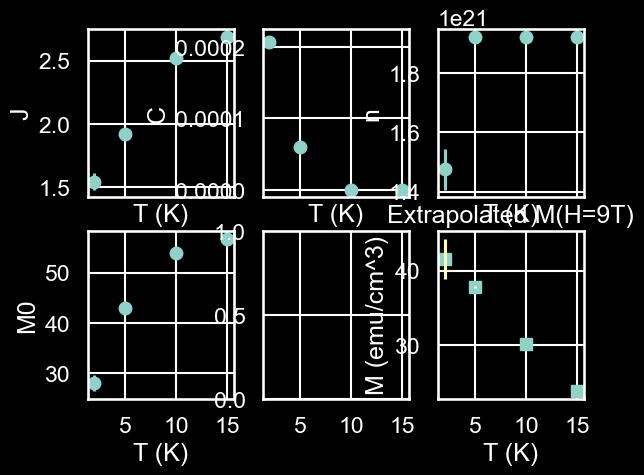

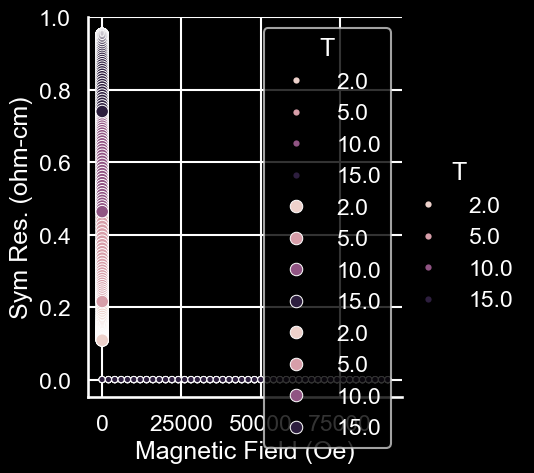

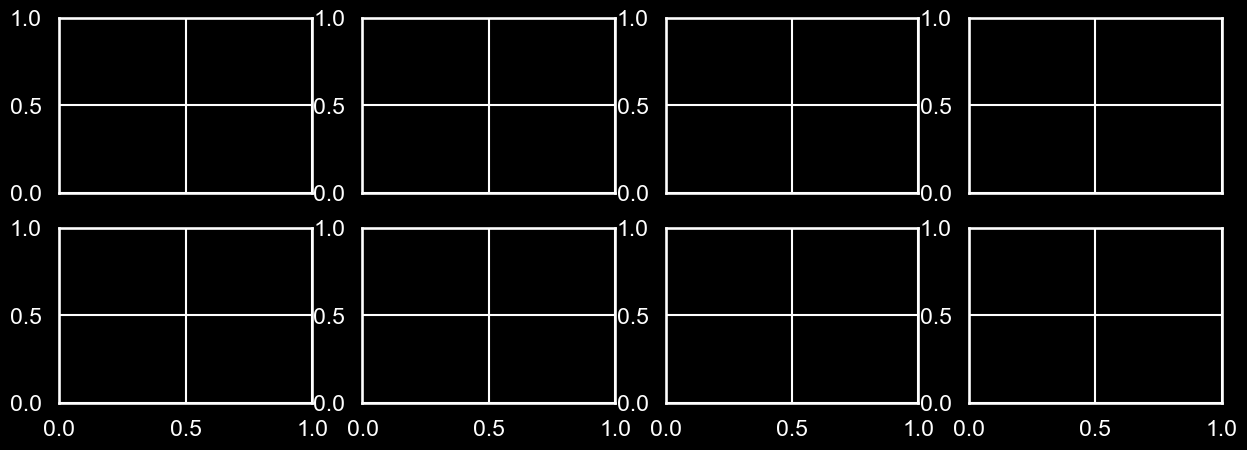

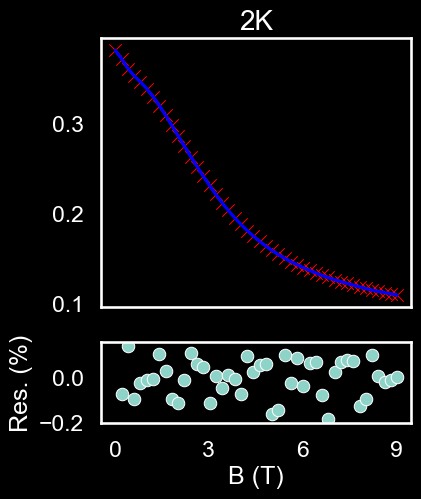

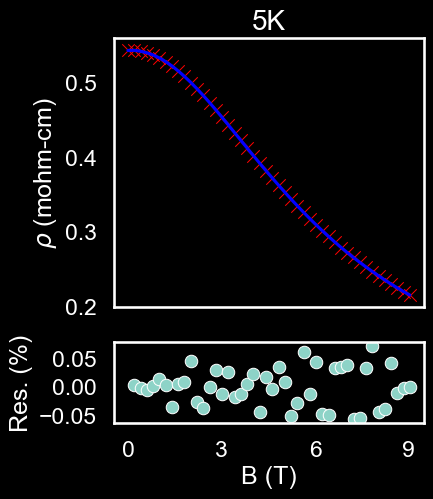

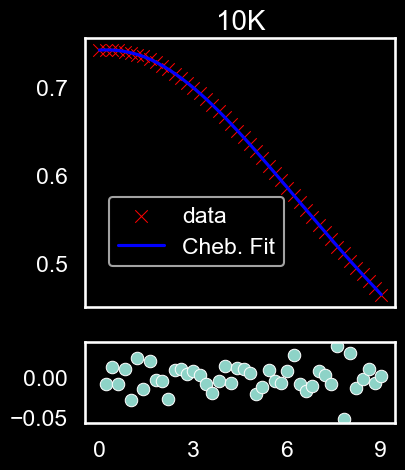

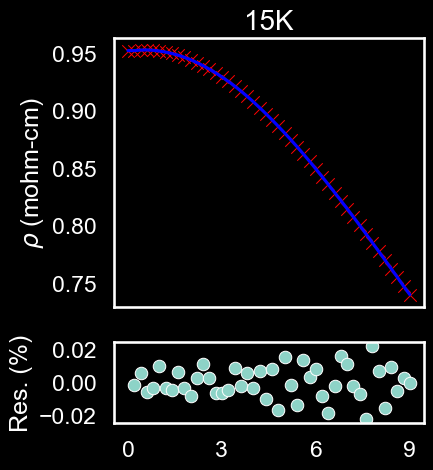

In [19]:

temps = [2, 5, 10, 15]
pl.plot_cheb_fits(B_MR_df, RvB_cheb_coeffs, RvB_cheb_residuals, T_vals)


# Calculate Demag Amplitudes For all ACTRot12 and ACTRot12's

## Calculate $M_{vol}$ and B for AMRO Data 

### Load All AMRO Datasets and Select $0^\circ$ and $90^\circ$

In [20]:
# Res = chebval(plot_x, RvB_cheb_coeffs[T])

max_positions = [0.1, 90.1, 180.1, 270.1, 360.1]
min_positions = [-0.1, 89.9, 179.9, 269.9, 359.9]

deg_label = 'Sample Position (deg)'
res_label = 'Res. (ohm-cm)'
geo_label = 'geo'

# Select only the orientations parallel or perpendicular to the field
amro_df = pd.read_csv(data_path/'YbPdBi_amro_combined.csv', sep=',')#.query('T >=2 & T<20 ')
amro_df = amro_df.query('ACT_str == "ACTRot12"')


amro_df['L (cm)']= 0.0786
amro_df['W (cm)']= 0.09172
amro_df['H (cm)'] =0.008020

# Get mean of each AMRO dataset, NOTE: probably don't need this, want mean of the expected MR data...
#amro_means = amro_df.groupby(['ACT_str', 'T', 'H', 'geo']).mean()[['Res.  (ohm-cm)']].reset_index().rename(columns = {'Res.  (ohm-cm)':'Mean Res. (ohm-cm)'})

# Prepare query string to get the desired sample orientations
deg_q = ''
for deg_min, deg_max in zip(min_positions, max_positions):
    deg_q+= '(`{}` > {} & `{}` < {})'.format(deg_label, deg_min, deg_label, deg_max)
    deg_q+= "|"
deg_q = deg_q[:-1]

# Query for just the desired orientations, and round for an easier life
amro_angles_df = amro_df.query(deg_q)
amro_angles_df[deg_label] = amro_angles_df[deg_label].round()

print(amro_angles_df[deg_label].unique())
amro_angles_df.query('ACT_str=="ACTRot12"').head(5)

[  0.  90. 180. 270.]


C:\Users\jdcf5\AppData\Local\Temp\ipykernel_29632\3093905044.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  amro_angles_df[deg_label] = amro_angles_df[deg_label].round()


,ACT_str,T,H,geo,Sample Position (deg),Sample Position (rads),Res. (ohm-cm),Res. (uohm-cm),Delta Res. Mean (ohm-cm),Delta Res. Mean (uohm-cm),Delta Res./R0 Mean,Delta Res./R0 Mean (%),Delta Res. 0deg (ohm-cm),Delta Res. 0deg (uohm-cm),Delta Res./R0 0deg,Delta Res./R0 0deg (%),L (cm),W (cm),H (cm)
2924,ACTRot12,15.0,0.5,perpendicular,0.0,0.000000,0.002416,2416.319474,6.382695e-07,0.638269,0.000264,0.026422,0.000000e+00,0.000000,0.000000,0.000000,0.0786,0.09172,0.00802
3014,ACTRot12,15.0,0.5,perpendicular,90.0,1.571048,0.002415,2415.100772,-5.804325e-07,-0.580432,-0.000240,-0.024028,-1.218702e-06,-1.218702,-0.000504,-0.050436,0.0786,0.09172,0.00802
3103,ACTRot12,15.0,0.5,perpendicular,180.0,3.142095,0.002416,2416.433056,7.518518e-07,0.751852,0.000311,0.031124,1.135823e-07,0.113582,0.000047,0.004701,0.0786,0.09172,0.00802
3192,ACTRot12,15.0,0.5,perpendicular,270.0,4.712214,0.002415,2415.228884,-4.523204e-07,-0.452320,-0.000187,-0.018724,-1.090590e-06,-1.090590,-0.000451,-0.045134,0.0786,0.09172,0.00802
3282,ACTRot12,15.0,3.0,perpendicular,0.0,0.000000,0.002355,2354.746395,9.746283e-07,0.974628,0.000414,0.041407,0.000000e+00,0.000000,0.000000,0.000000,0.0786,0.09172,0.00802


In [21]:
print(amro_angles_df.columns) # ['ACT_str'].unique())

Index(['ACT_str', 'T', 'H', 'geo', 'Sample Position (deg)',
       'Sample Position (rads)', 'Res. (ohm-cm)', 'Res. (uohm-cm)',
       'Delta Res. Mean (ohm-cm)', 'Delta Res. Mean (uohm-cm)',
       'Delta Res./R0 Mean ', 'Delta Res./R0 Mean  (%)',
       'Delta Res. 0deg (ohm-cm)', 'Delta Res. 0deg (uohm-cm)',
       'Delta Res./R0 0deg ', 'Delta Res./R0 0deg  (%)', 'L (cm)', 'W (cm)',
       'H (cm)'],
      dtype='object')


## Join AMRO orientation data with relevant Brillouin fit parameters

In [22]:
# Left join with relevant fit parameters of Brillouin fits
amro_angles_with_fit_params_df = amro_angles_df.merge(lmfit_params_df, on='T')

print('Initial Shape: # Rows=', amro_angles_df.shape[0],', # Columns =',amro_angles_df.shape[1])
print('Joined Shape: # Rows=', amro_angles_with_fit_params_df.shape[0],', # Columns =',amro_angles_with_fit_params_df.shape[1])
print('\nChanged due to a reduction in T values.')
print('Initial unique T values:', amro_angles_df['T'].unique())
print('Joined unique T values:', amro_angles_with_fit_params_df['T'].unique())

Initial Shape: # Rows= 64 , # Columns = 19
Joined Shape: # Rows= 64 , # Columns = 32

Changed due to a reduction in T values.
Initial unique T values: [15. 10.  5.  2.]
Joined unique T values: [15. 10.  5.  2.]


## Calulate D Factors, Solve for $M_{vol}$, and determine B Fields

In [23]:
amro_angles_with_fit_params_df.columns

Index(['ACT_str', 'T', 'H', 'geo', 'Sample Position (deg)',
       'Sample Position (rads)', 'Res. (ohm-cm)', 'Res. (uohm-cm)',
       'Delta Res. Mean (ohm-cm)', 'Delta Res. Mean (uohm-cm)',
       'Delta Res./R0 Mean ', 'Delta Res./R0 Mean  (%)',
       'Delta Res. 0deg (ohm-cm)', 'Delta Res. 0deg (uohm-cm)',
       'Delta Res./R0 0deg ', 'Delta Res./R0 0deg  (%)', 'L (cm)', 'W (cm)',
       'H (cm)', 'J', 'J_err', 'C', 'C_err', 'n', 'n_err', 'D', 'M0', 'M0_err',
       'C (T)', 'C (T)_err', 'n (mols)', 'n (mols)_err'],
      dtype='object')

In [24]:
amro_angles_with_fit_params_df['ACT_str'].unique()
amro_angles_with_fit_params_df.head()

,ACT_str,T,H,geo,Sample Position (deg),Sample Position (rads),Res. (ohm-cm),Res. (uohm-cm),Delta Res. Mean (ohm-cm),Delta Res. Mean (uohm-cm),...,C_err,n,n_err,D,M0,M0_err,C (T),C (T)_err,n (mols),n (mols)_err
0,ACTRot12,15.0,0.5,perpendicular,0.0,0.000000,0.002416,2416.319474,6.382695e-07,0.638269,...,0.0,1.920550e+21,0.0,0.400857,56.74754,0.010791,0.0,0.0,0.003189,0.0
1,ACTRot12,15.0,0.5,perpendicular,90.0,1.571048,0.002415,2415.100772,-5.804325e-07,-0.580432,...,0.0,1.920550e+21,0.0,0.400857,56.74754,0.010791,0.0,0.0,0.003189,0.0
2,ACTRot12,15.0,0.5,perpendicular,180.0,3.142095,0.002416,2416.433056,7.518518e-07,0.751852,...,0.0,1.920550e+21,0.0,0.400857,56.74754,0.010791,0.0,0.0,0.003189,0.0
3,ACTRot12,15.0,0.5,perpendicular,270.0,4.712214,0.002415,2415.228884,-4.523204e-07,-0.452320,...,0.0,1.920550e+21,0.0,0.400857,56.74754,0.010791,0.0,0.0,0.003189,0.0
4,ACTRot12,15.0,3.0,perpendicular,0.0,0.000000,0.002355,2354.746395,9.746283e-07,0.974628,...,0.0,1.920550e+21,0.0,0.400857,56.74754,0.010791,0.0,0.0,0.003189,0.0


In [25]:
# Can be lazy and just calculate D multiple times and differentiate by column name
# D0 can be calculated at the same time for both geometries since the first two parameters of h.DemagFactor
# NOTE:
# Third entry to h.DemagFactor must be parallel to the applied magnetic field
print('Deg zero test:', fo.DemagFactor(1, 2, 3), fo.DemagFactor(2, 1, 3))
D_list = []
B_list = []
AMRO_mag = []

amro_angles_mag_B_df = amro_angles_with_fit_params_df.copy()

for index, row in amro_angles_with_fit_params_df.iterrows():
    
    if row[deg_label] in [0, 180, 360]:
        
            D = fo.DemagFactor(row['L (cm)'] / 2.0, row['W (cm)'] / 2.0, row['H (cm)'] / 2.0)
            H =row['H']

            T = row['T']
            J = row['J']
            C =row['C']
            n =row['n']
            M = ex.solve_for_magnetization(H, D, T, J, C, n)
            
            
            B = row['H'] + (4*np.pi) * (1-D) * M# chebval( row['Abs. Magnetic Field (Oe)'], MvH_cheb_coeffs[T])
            
            D_list.append(D)
            B_list.append(B)
            AMRO_mag.append(M)
    elif row[deg_label] in [90, 270]:  
        if 'para' in row[geo_label]:


            D = fo.DemagFactor(row['H (cm)'] / 2.0, row['W (cm)'] / 2.0, row['L (cm)'] / 2.0)
            H =row['H']

            T = row['T']
            J = row['J']
            C =row['C']
            n =row['n']
            M = ex.solve_for_magnetization(H, D, T, J, C, n)
            
            
            #print(row['Abs. Magnetic Field (Oe)']+(4*np.pi)*(1-D) * chebval( row['Abs. Magnetic Field (Oe)'], MvH_cheb_coeffs[T]))
            
            B = row['H'] + (4*np.pi)*(1-D) * M#chebval( row['Abs. Magnetic Field (Oe)'], MvH_cheb_coeffs[T])

            D_list.append(D)
            B_list.append(B)
            AMRO_mag.append(M)

        
        elif  'perp' in row[geo_label]:
            if row[deg_label] in [90, 270]:
                D = fo.DemagFactor(row['L (cm)'] / 2.0, row['H (cm)'] / 2.0, row['W (cm)'] / 2.0)

                H =row['H']

                T = row['T']
                J = row['J']
                C =row['C']
                n =row['n']
                M = ex.solve_for_magnetization(H, D, T, J, C, n)
            
                B = row['H'] + (4*np.pi)*(1-D) * M#chebval( row['Abs. Magnetic Field (Oe)'], MvH_cheb_coeffs[T])

                D_list.append(D)
                B_list.append(B)
                AMRO_mag.append(M)
        else:
            print('Weird Row')
            print(row)
            continue        


amro_angles_mag_B_df['D'] = np.array(D_list) 
amro_angles_mag_B_df['Magnetic Flux Density (G)']  = B_list   
amro_angles_mag_B_df['Magnetization (emu/cm^3)'] = AMRO_mag

amro_angles_mag_B_df.head(5)

Deg zero test: 0.18281797804039265 0.18281797804039293


C:\Users\jdcf5\Documents\Data Science Portfolio\Python\MSc Data Analyses\Magnetization Extrapolation\extrapolation.py:18: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  return fsolve(func, [20])[0]


,ACT_str,T,H,geo,Sample Position (deg),Sample Position (rads),Res. (ohm-cm),Res. (uohm-cm),Delta Res. Mean (ohm-cm),Delta Res. Mean (uohm-cm),...,n_err,D,M0,M0_err,C (T),C (T)_err,n (mols),n (mols)_err,Magnetic Flux Density (G),Magnetization (emu/cm^3)
0,ACTRot12,15.0,0.5,perpendicular,0.0,0.000000,0.002416,2416.319474,6.382695e-07,0.638269,...,0.0,0.812159,56.74754,0.010791,0.0,0.0,0.003189,0.0,0.500437,0.000185
1,ACTRot12,15.0,0.5,perpendicular,90.0,1.571048,0.002415,2415.100772,-5.804325e-07,-0.580432,...,0.0,0.086358,56.74754,0.010791,0.0,0.0,0.003189,0.0,0.502135,0.000186
2,ACTRot12,15.0,0.5,perpendicular,180.0,3.142095,0.002416,2416.433056,7.518518e-07,0.751852,...,0.0,0.812159,56.74754,0.010791,0.0,0.0,0.003189,0.0,0.500437,0.000185
3,ACTRot12,15.0,0.5,perpendicular,270.0,4.712214,0.002415,2415.228884,-4.523204e-07,-0.452320,...,0.0,0.086358,56.74754,0.010791,0.0,0.0,0.003189,0.0,0.502135,0.000186
4,ACTRot12,15.0,3.0,perpendicular,0.0,0.000000,0.002355,2354.746395,9.746283e-07,0.974628,...,0.0,0.812159,56.74754,0.010791,0.0,0.0,0.003189,0.0,3.002625,0.001112


### D-Factor Ratios

In [26]:
for num in ['12']:  # ['11', '12', '13', '14']:
    pr_df = amro_angles_mag_B_df.query('ACT_str == "{}"'.format("ACTRot"+num))
    # pr_df = pr_df.query('`Sample Position (deg)` in (0, 90)')[['Sample Position (deg)', 'D']]
    pr_df = pr_df[['Sample Position (deg)', 'D']]
    print(num)
    print(pr_df.head(2))
    print('Ratio:', pr_df['D'].iloc[1]/ pr_df['D'].iloc[0])
    print()

12
   Sample Position (deg)         D
0                    0.0  0.812159
1                   90.0  0.086358
Ratio: 0.10633173050083608



### Plot to Check Magnetization Approximation

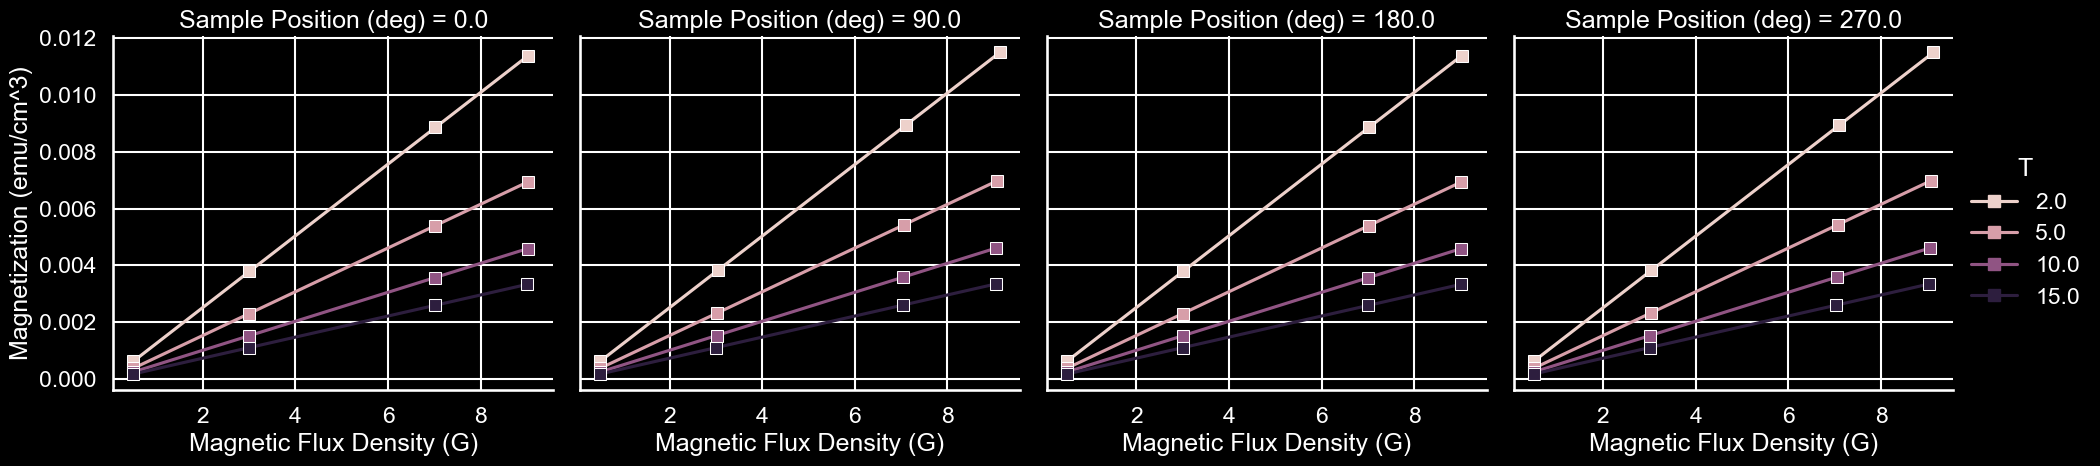

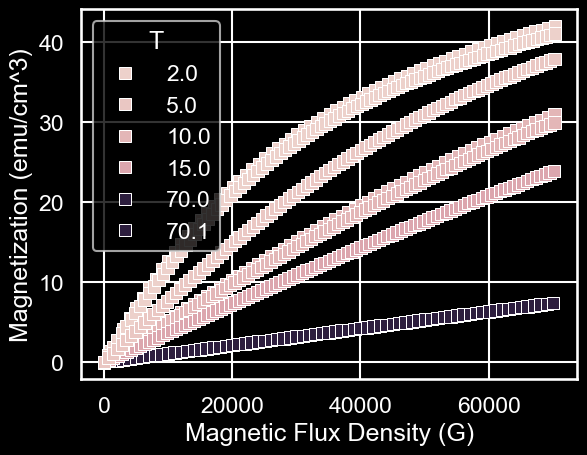

In [27]:
x_label = 'Magnetic Flux Density (G)'
y_label = 'Magnetization (emu/cm^3)' 

#q = '(`{}`==0 | `{}`==90)'.format(deg_label, deg_label)
plot_df = amro_angles_mag_B_df#.query(q)#.sort_values(['T', 'H', x_label])

g=sns.relplot(x=x_label, y= y_label, hue='T', kind='line',marker='s', col = deg_label, data=plot_df)
plt.show()
g =sns.scatterplot(x=x_label, y= y_label, marker='s', hue='T', data=mag_data.reset_index(drop=True))
plt.show()

### Plot Resistivity to Check Field Conversion

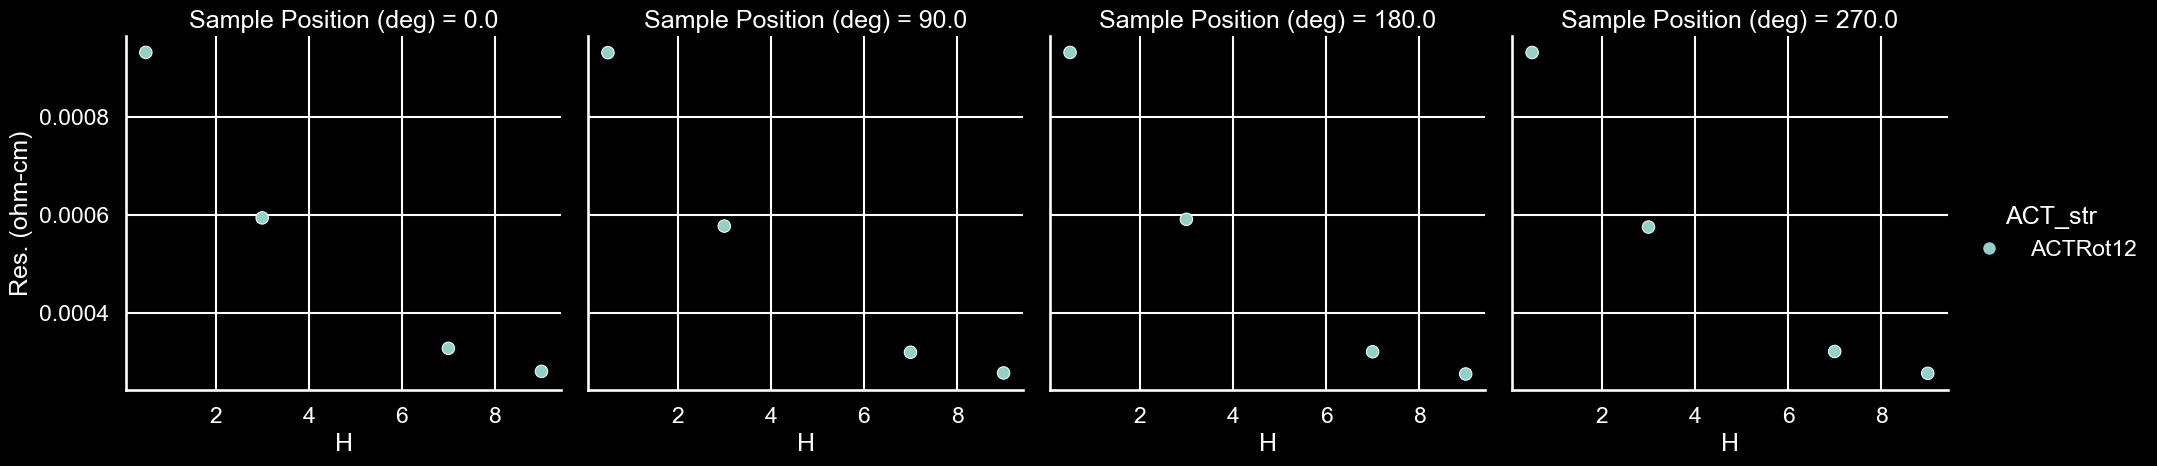

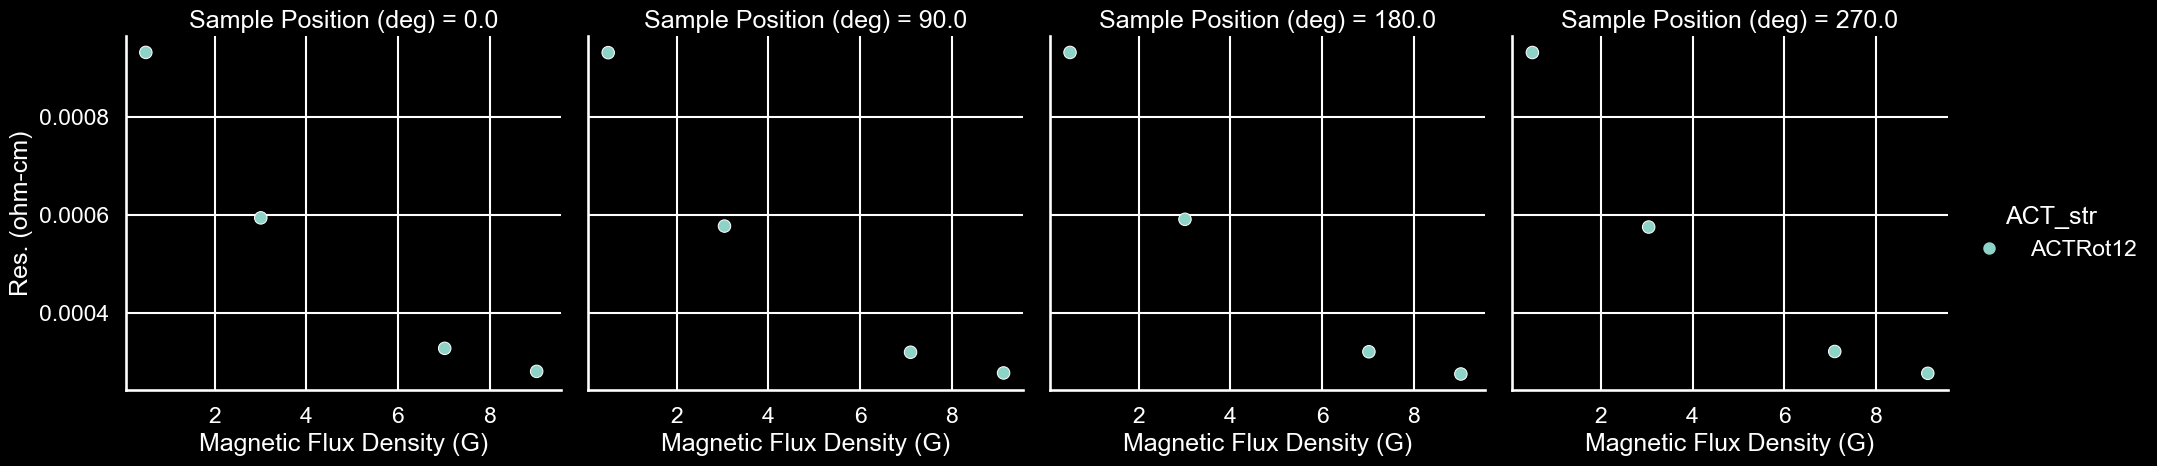

In [28]:
sns.set_context('talk')

#sns.relplot(x=deg_label, y= res_label, col='T', hue = 'Magnetic Flux Density (G)', data=amro_df)
plot_T = 2
plot_df = amro_angles_mag_B_df.query('T=={}'.format(plot_T))
g = sns.relplot(x='H', # 'Abs. Magnetic Field (Oe)',
            y= res_label, hue='ACT_str', col=deg_label, data=plot_df)
plt.show()
g = sns.relplot(x='Magnetic Flux Density (G)',
            y= res_label, hue='ACT_str', col=deg_label, data=plot_df)
plt.show()

## Use MR Chebyshev to find $a_{dem}$ for each ACTRot# at each T and B

Will have 2-fold Symmetry from square-ness of each sample's cross-section.

Could be a problem if we later find that the mechanical offset is significant, and that the resistivity at the desired angles changes a lot between these angles, ...

### Get expected Magnetoresistivities from RvB Chebyshev fit

In [29]:
dem_res_list = []
meaned_dem_res_list = []
for index, row in amro_angles_mag_B_df.iterrows():
    res = ip.evaluate_cheb(row['Magnetic Flux Density (G)'], RvB_cheb_coeffs[int(row['T'])])

    dem_res_list.append(res)


amro_angles_mag_B_df['Cheb. MR Res.'] = dem_res_list


### Plot a_dem vs sample position, for both Geometries

In [30]:
# Take average of abs values of, (90-0), (180-90), (180-0) (270-180), (360-270)
sns.set_context('talk')
plot_df = amro_angles_mag_B_df.query('T<10')
a = sns.relplot(x=deg_label, y='Cheb. MR Res.' , data = plot_df, col='H', row ='T', hue ='ACT_str', facet_kws={'sharey': False})



Since they're all gonna the be the same, may as well just take half the difference between 0 and 90

### Obtain the Demag Amplitudes by taking half the difference between 0 and 90, and dividing by their mean value

In [31]:
# For all take Half the Difference Between Valus at 0 and 90
amro_angles_mag_B_df['Delta MR Res.'] = amro_angles_mag_B_df['Cheb. MR Res.']-amro_angles_mag_B_df['Cheb. MR Res.'].shift(1)
amro_angles_mag_B_df['Mean Demag. Res.'] = (amro_angles_mag_B_df['Cheb. MR Res.']+amro_angles_mag_B_df['Cheb. MR Res.'].shift(1))/2

amro_angles_mag_B_df['amp_res'] = amro_angles_mag_B_df['Delta MR Res.']/2
amro_angles_mag_B_df['a_dem (%)'] = amro_angles_mag_B_df['amp_res']/amro_angles_mag_B_df['Mean Demag. Res.']*100
amro_angles_mag_B_df['abs. a_dem (%)'] =amro_angles_mag_B_df['a_dem (%)'].abs()


# Calculate some other stuff that may be interesting later
amro_angles_mag_B_df['Delta B (G)'] =  (amro_angles_mag_B_df['Magnetic Flux Density (G)']-amro_angles_mag_B_df['Magnetic Flux Density (G)'].shift(1))
amro_angles_mag_B_df['D90/D0'] =  (amro_angles_mag_B_df['D']/amro_angles_mag_B_df['D'].shift(1))


amro_angles_mag_B_df.query('ACT_str=="ACTRot12"').head(10)

,ACT_str,T,H,geo,Sample Position (deg),Sample Position (rads),Res. (ohm-cm),Res. (uohm-cm),Delta Res. Mean (ohm-cm),Delta Res. Mean (uohm-cm),...,Magnetic Flux Density (G),Magnetization (emu/cm^3),Cheb. MR Res.,Delta MR Res.,Mean Demag. Res.,amp_res,a_dem (%),abs. a_dem (%),Delta B (G),D90/D0
0,ACTRot12,15.0,0.5,perpendicular,0.0,0.000000,0.002416,2416.319474,6.382695e-07,0.638269,...,0.500437,0.000185,0.000952,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ACTRot12,15.0,0.5,perpendicular,90.0,1.571048,0.002415,2415.100772,-5.804325e-07,-0.580432,...,0.502135,0.000186,0.000952,-7.222635e-13,0.000952,-3.611318e-13,-3.793218e-08,3.793218e-08,0.001698,0.106332
2,ACTRot12,15.0,0.5,perpendicular,180.0,3.142095,0.002416,2416.433056,7.518518e-07,0.751852,...,0.500437,0.000185,0.000952,7.222635e-13,0.000952,3.611318e-13,3.793218e-08,3.793218e-08,-0.001698,9.404530
3,ACTRot12,15.0,0.5,perpendicular,270.0,4.712214,0.002415,2415.228884,-4.523204e-07,-0.452320,...,0.502135,0.000186,0.000952,-7.222635e-13,0.000952,-3.611318e-13,-3.793218e-08,3.793218e-08,0.001698,0.106332
4,ACTRot12,15.0,3.0,perpendicular,0.0,0.000000,0.002355,2354.746395,9.746283e-07,0.974628,...,3.002625,0.001112,0.000952,-1.061569e-09,0.000952,-5.307843e-10,-5.575200e-05,5.575200e-05,2.500490,9.404530
5,ACTRot12,15.0,3.0,perpendicular,90.0,1.571048,0.002352,2352.382935,-1.388832e-06,-1.388832,...,3.012811,0.001116,0.000952,-4.315094e-12,0.000952,-2.157547e-12,-2.266224e-07,2.266224e-07,0.010186,0.106332
6,ACTRot12,15.0,3.0,perpendicular,180.0,3.142095,0.002355,2355.244232,1.472465e-06,1.472465,...,3.002625,0.001112,0.000952,4.315094e-12,0.000952,2.157547e-12,2.266224e-07,2.266224e-07,-0.010186,9.404530
7,ACTRot12,15.0,3.0,perpendicular,270.0,4.712214,0.002352,2352.169359,-1.602408e-06,-1.602408,...,3.012811,0.001116,0.000952,-4.315094e-12,0.000952,-2.157547e-12,-2.266224e-07,2.266224e-07,0.010186,0.106332
8,ACTRot12,15.0,7.0,perpendicular,0.0,0.000000,0.002060,2059.628150,1.325449e-06,1.325449,...,7.006125,0.002595,0.000952,-1.685926e-09,0.000952,-8.429631e-10,-8.854246e-05,8.854246e-05,3.993314,9.404530
9,ACTRot12,15.0,7.0,perpendicular,90.0,1.571048,0.002056,2056.369586,-1.933115e-06,-1.933115,...,7.029892,0.002604,0.000952,-9.999658e-12,0.000952,-4.999829e-12,-5.251684e-07,5.251684e-07,0.023767,0.106332


### Extract Amplitudes for Each AMRO Experiment 
Only get amplitudes for when deg=90, since deg=0 will have overlap between experiments due to how $a_{dem}$ were calculated

In [32]:
#Extract amplitudes from each experiment
q = '`{}` =={}'.format(deg_label, 180)
final_90_df = amro_angles_mag_B_df.query(q)

# Select only relevant columns
chosen_columns = ['ACT_str','geo',  'T', 'H', 'D',  'Sample Position (deg)',
                  'Res. (ohm-cm)',  'Magnetic Flux Density (G)',
                  'Magnetization (emu/cm^3)', 'Cheb. MR Res.', 'Delta MR Res.', 'Delta B (G)',  'D90/D0',
                  'Mean Demag. Res.', 'amp_res', 'a_dem (%)','abs. a_dem (%)']
final_df = final_90_df[chosen_columns].reset_index(drop=True)


# final_df.head(16)

In [33]:
for act_num in [11, 12, 13, 14]:
    print('ACT_str',act_num, 'shape:')
    print(final_df.query('ACT_str=="ACTRot{}"'.format(act_num)).shape)


ACT_str 11 shape:
(0, 17)
ACT_str 12 shape:
(16, 17)
ACT_str 13 shape:
(0, 17)
ACT_str 14 shape:
(0, 17)


### Plot a_dem vs Temperature, for both Geometries

In [34]:
final_df['H']#.head()

0     0.5
1     3.0
2     7.0
3     9.0
4     0.5
5     3.0
6     7.0
7     9.0
8     0.5
9     3.0
10    7.0
11    9.0
12    0.5
13    3.0
14    7.0
15    9.0
Name: H, dtype: float64

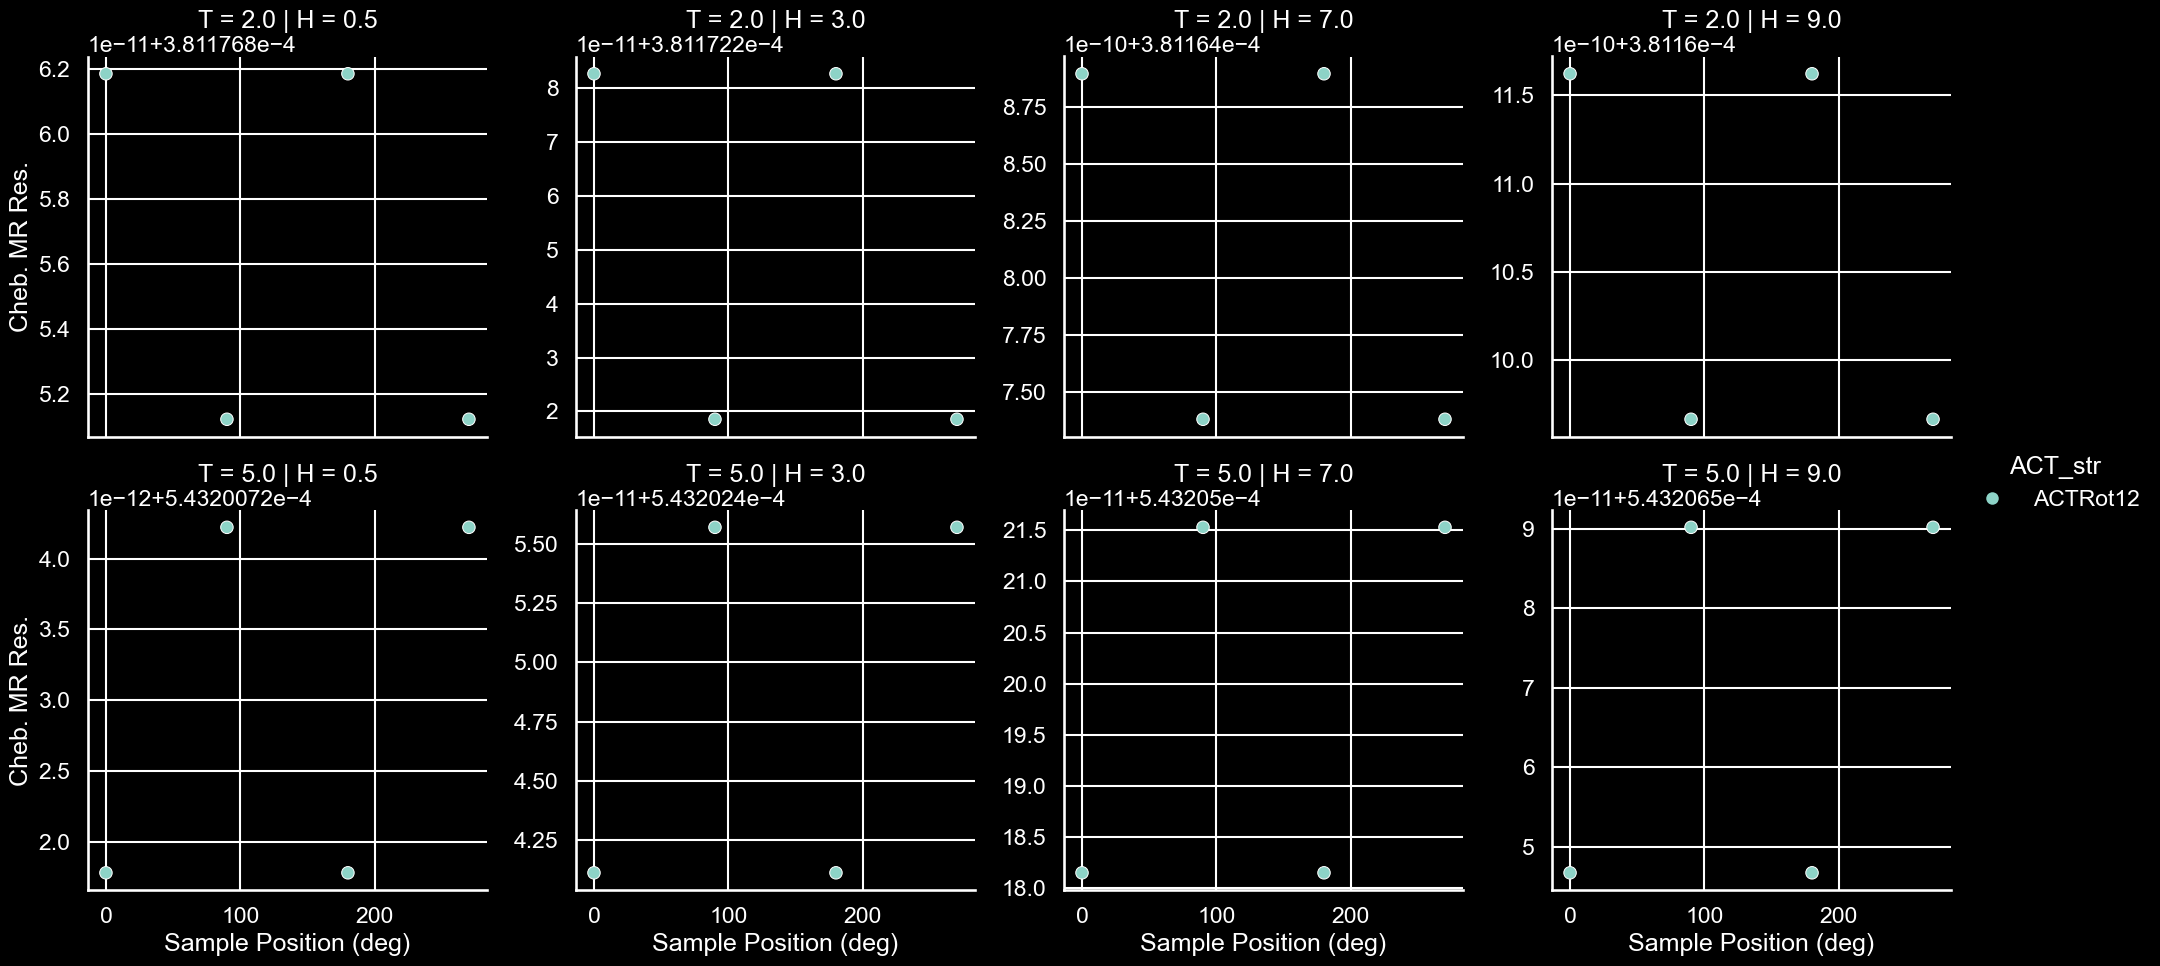

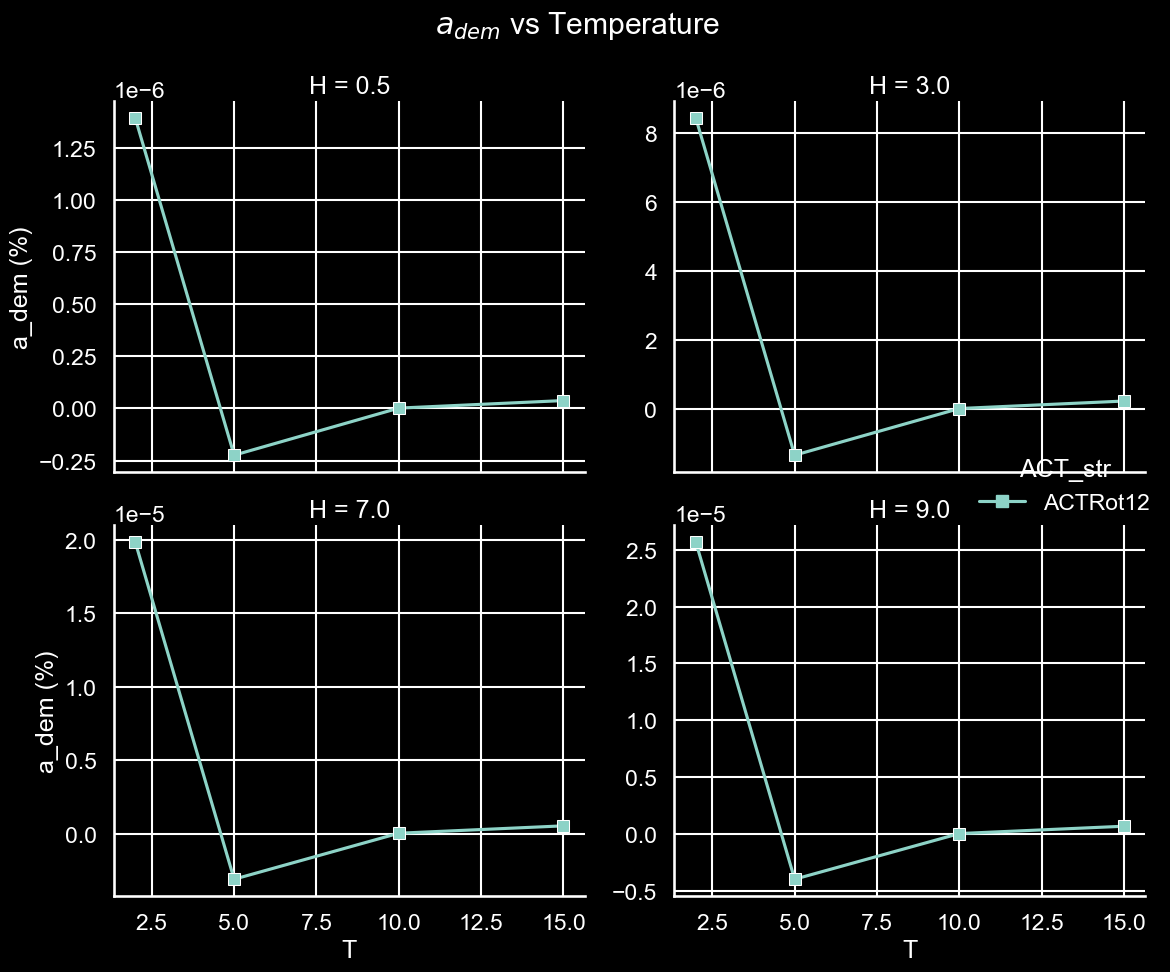

In [35]:
g = sns.relplot(x='T',
                y='a_dem (%)',  # 'Sample Position (deg)', # 'Delta B (G)', # 
                data = final_df,
                col='H', col_wrap=2, kind='line', marker='s',
                errorbar=None,
                hue ='ACT_str',
                facet_kws={'sharey':False})
g.figure.suptitle('$a_{dem}$ vs Temperature')
#h._legend.remove()

plt.tight_layout()
plt.show()

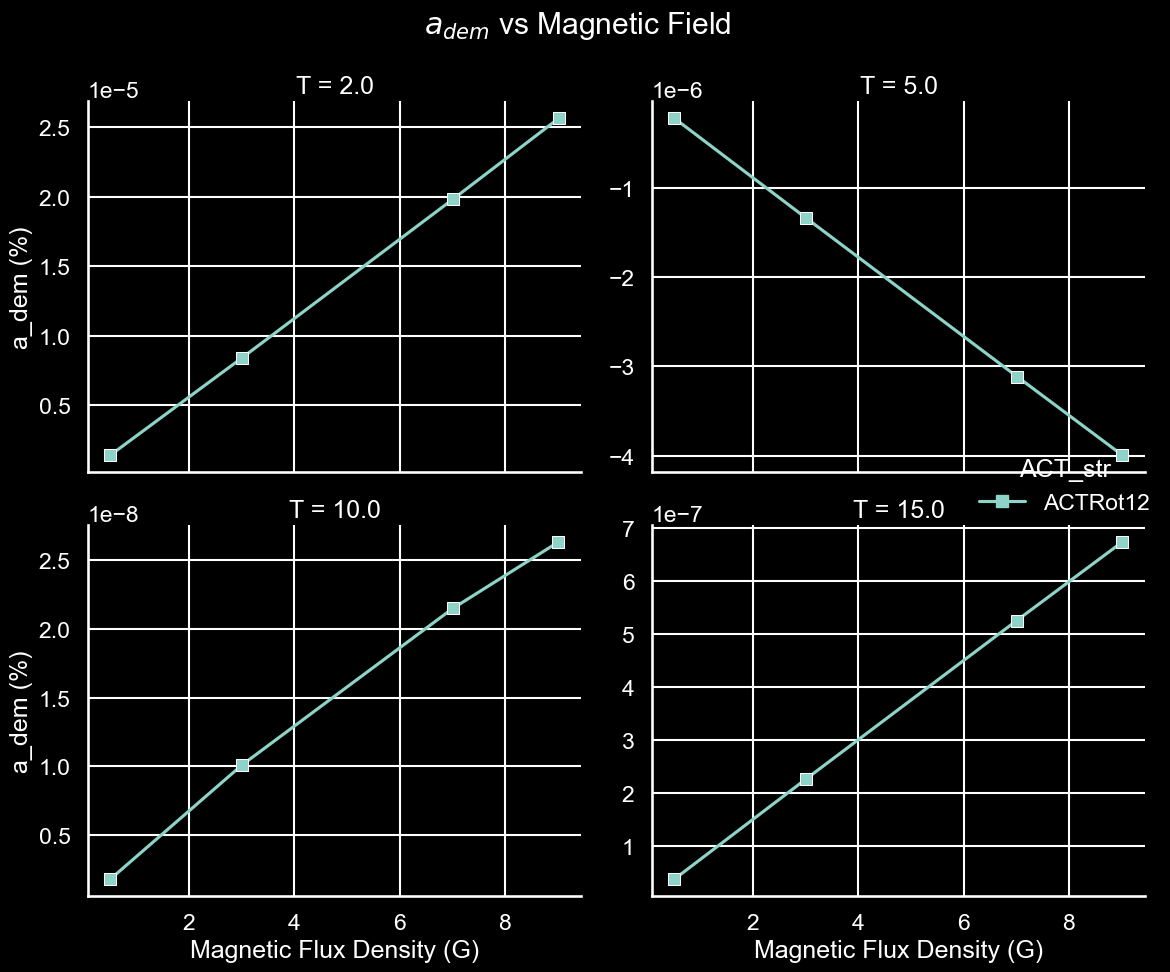

In [36]:
g = sns.relplot(x='Magnetic Flux Density (G)', y='a_dem (%)', data = final_df,
                col='T',  col_wrap=2, kind='line', marker='s', 
                errorbar=None, hue ='ACT_str', facet_kws={'sharey':False})
g.figure.suptitle('$a_{dem}$ vs Magnetic Field')
#h._legend.remove()
plt.tight_layout()
plt.show()

### Save the Results

In [37]:
final_df.to_csv(data_path/'YbPdBi_amro_combined_demag_amplitudes.csv', sep=',')


### Plot Amplitudes FOR THE THESIS

In [38]:
x_label =  'B (T)'# 'Magnetic Flux Density (G)'
col_label = 'T'
final_df[x_label] = final_df['Magnetic Flux Density (G)']#/10000

q='ACT_str in ("ACTRot12", "ACTRot12")'
plot_df = final_df.query(q)
plot_df['Label'] = np.where(plot_df['ACT_str'] == "ACTRot12",
                                  r'Sample Puck 11 $\perp$',
                                  r'Sample Puck 13 $||$'
                                 )
g = sns.relplot(x=x_label, y='abs. a_dem (%)', data = plot_df,
                col =col_label, hue = 'Label', kind='line', col_wrap=2,
                marker='s', ci=None, facet_kws={'sharey':False})#, hue='M')

# g.figure.suptitle(r'$|a_{dem}|$ vs. B', fontsize=30)#, y=1.03)
g.set_ylabels(r"$|a_{dem}|$ (%)")

# # Adjust the legend labels
fig_legend = g._legend
# fig_legend.remove()
# #fig_legend.set_bbox_to_anchor([0.98, 0.725])
# geos = ['Perp', 'Para', 'Para','Perp']
# for i,t in enumerate(fig_legend.texts):
#     t.set_text(t.get_text()+", "+geos[i])
# plt.tight_layout()
# plt.show()
g.figure.savefig(figure_path/'Demag Amplitudes vs B.pdf'.format(x_label), dpi=300, transparent=False, bbox_inches='tight')


C:\Users\jdcf5\anaconda3\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
C:\Users\jdcf5\anaconda3\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
C:\Users\jdcf5\anaconda3\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
C:\Users\jdcf5\anaconda3\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)


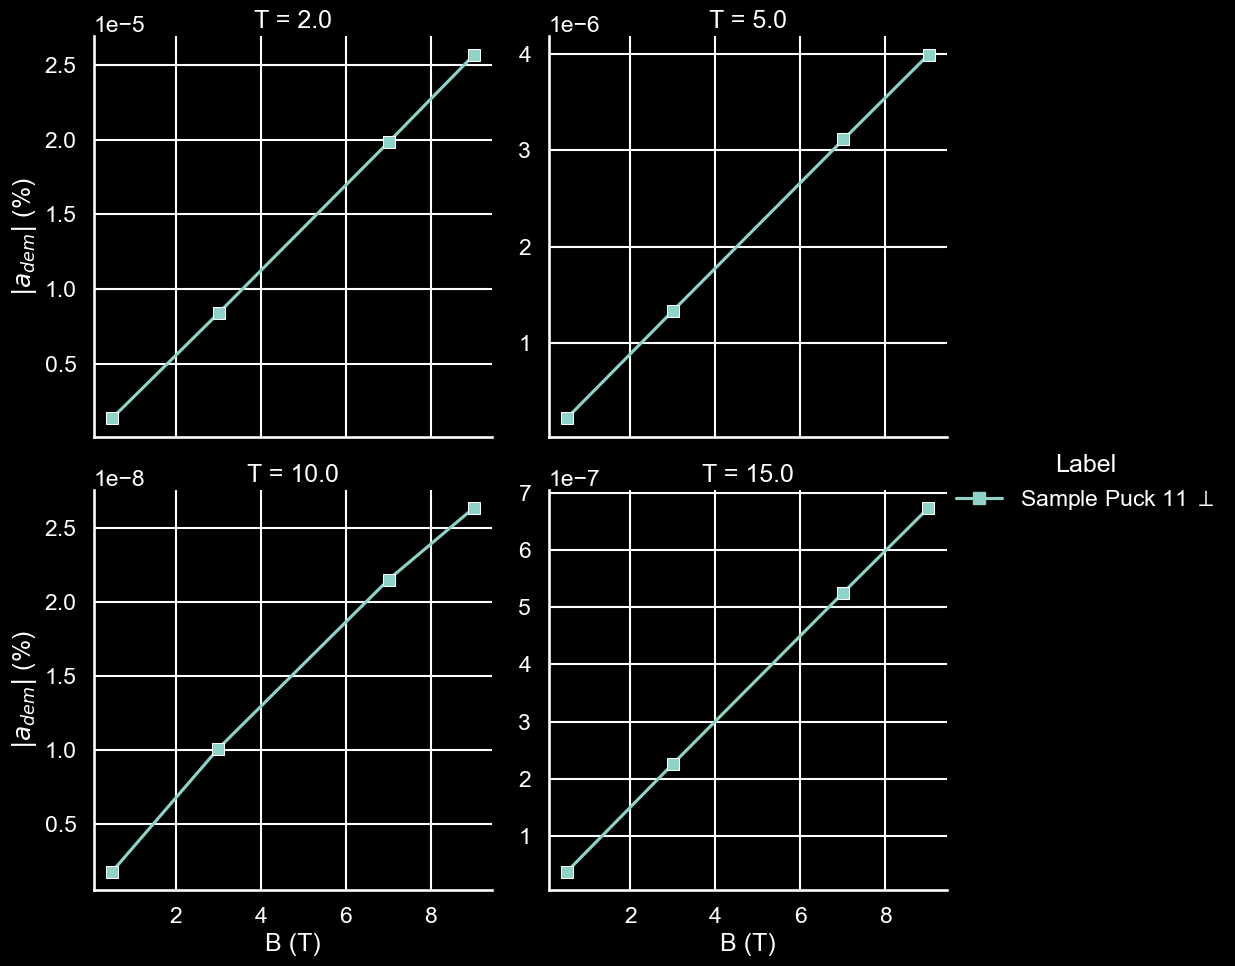

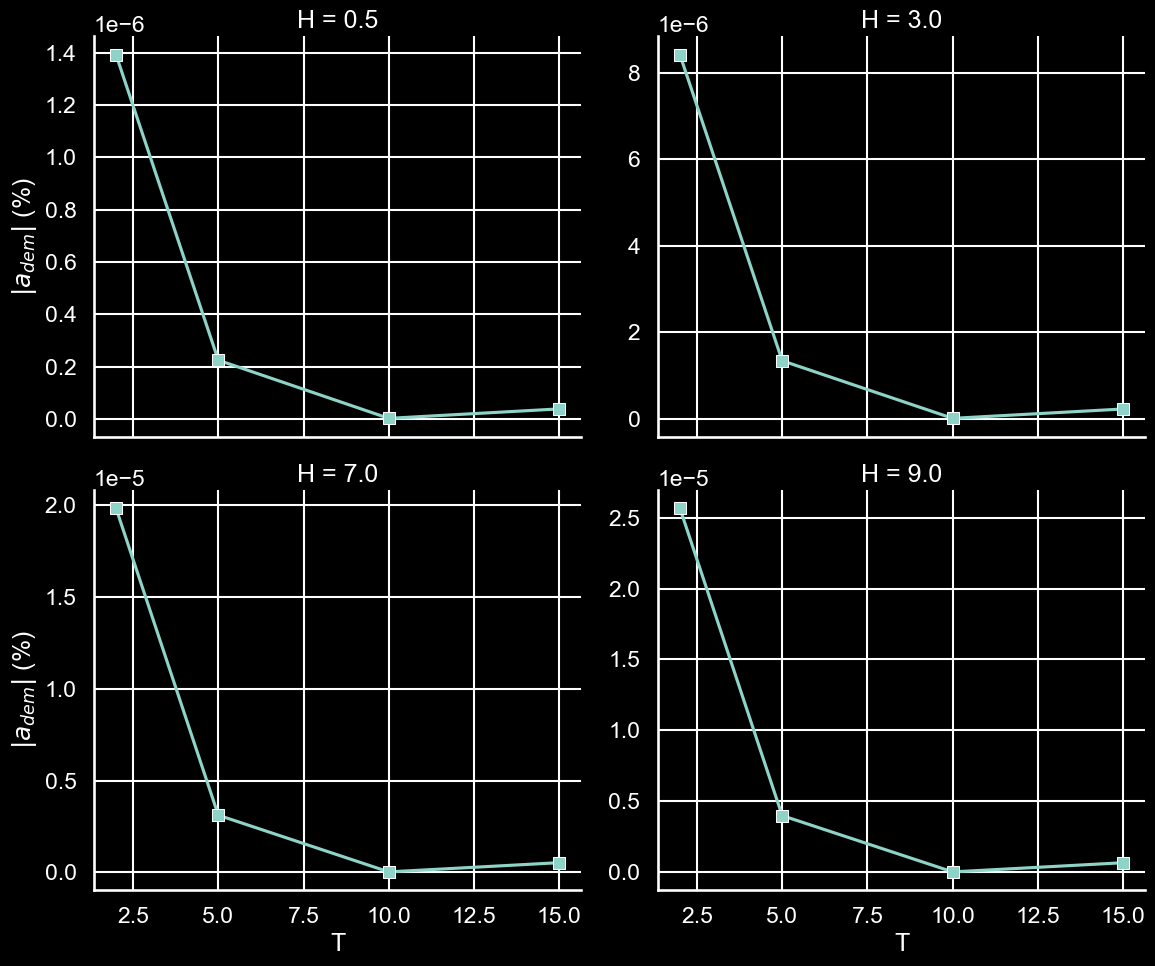

In [39]:
x_label = 'T'
col_label = 'H'


g = sns.relplot(x=x_label, y='abs. a_dem (%)', data = final_df,
                col =col_label, hue = 'ACT_str', kind='line', col_wrap=2,
                marker='s', errorbar=None, facet_kws={'sharey':False})#, hue='M')

g.set_ylabels(r"$|a_{dem}|$ (%)")

# # Adjust the legend labels
fig_legend = g._legend
fig_legend.remove()

plt.tight_layout()
plt.show()
g.figure.savefig(figure_path/'Demag Amplitudes vs {}.pdf'.format(x_label), dpi=300, transparent=False, bbox_inches='tight')


## Trouble with MR res vs AMRO res

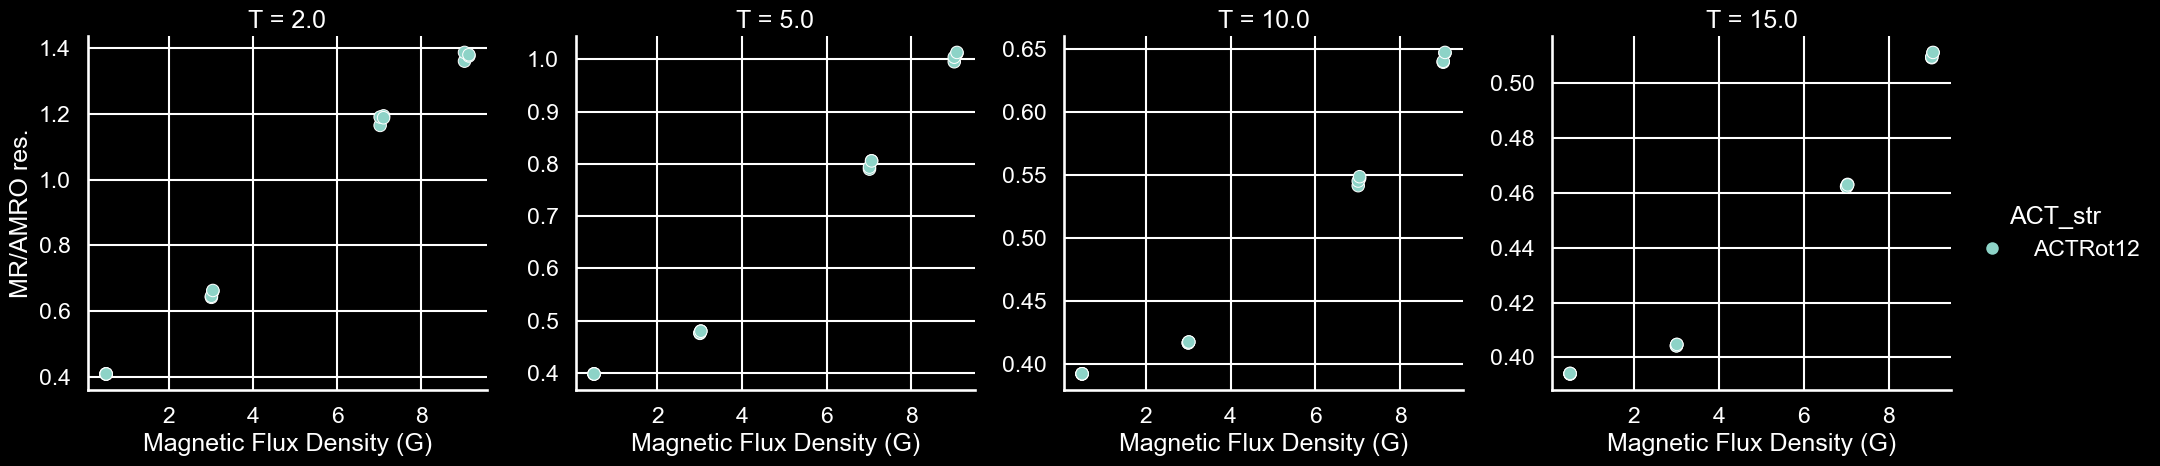

In [40]:
checkdf = amro_angles_mag_B_df.copy()
checkdf['MR/AMRO res.'] = checkdf['Cheb. MR Res.'] / checkdf['Res. (ohm-cm)']

g = sns.relplot(x='Magnetic Flux Density (G)', y='MR/AMRO res.',data = checkdf, hue='ACT_str',  col='T',facet_kws={'sharey':False, 'sharex':False})
plt.show()